In [1]:
library(tidyverse)
library(glue)

Warning message:
“package ‘tibble’ was built under R version 4.2.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
sessionInfo()

R version 4.2.1 (2022-06-23)
Platform: x86_64-apple-darwin13.4.0 (64-bit)
Running under: macOS Big Sur ... 10.16

Matrix products: default
BLAS/LAPACK: /Users/joonklaps/opt/anaconda3/lib/libopenblasp-r0.3.20.dylib

locale:
[1] C/C.UTF-8/C/C/C/C

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] glue_1.7.0      lubridate_1.9.3 forcats_1.0.0   stringr_1.5.1  
 [5] dplyr_1.1.4     purrr_1.0.2     readr_2.1.5     tidyr_1.3.1    
 [9] tibble_3.2.1    ggplot2_3.5.2   tidyverse_2.0.0

loaded via a namespace (and not attached):
 [1] pillar_1.10.2      compiler_4.2.1     RColorBrewer_1.1-3 base64enc_0.1-3   
 [5] tools_4.2.1        digest_0.6.36      uuid_1.2-0         timechange_0.3.0  
 [9] jsonlite_1.8.8     evaluate_1.0.3     lifecycle_1.0.4    gtable_0.3.6      
[13] pkgconfig_2.0.3    rlang_1.1.4        IRdisplay_1.1      cli_3.6.3         
[17] IRkernel_1.3.2     fastmap_1.2.0      repr_1.1.7         withr_3.0

In [6]:
galn <- read_tsv("./data-preparation/global-alignment/global_alignment_stats.tsv")
colnames_mmseqs <- c("query,target,fident,alnlen,mismatch,gapopen,qstart,qend,qlen,tstart,tend,tlen,evalue,bits")
mmseqs <- read_tsv("./data-preparation/mmseqs-results/MN090277.1_mmseqs.out.m8", col_names = str_split(colnames_mmseqs,",")[[1]])

Rows: 142 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (2): seq1_id, seq2_id
dbl (11): alignment_length, comparable_sites, matches, mismatches, mismatch_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 3935 Columns: 14
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (2): query, target
dbl (12): fident, alnlen, mismatch, gapopen, qstart, qend, qlen, tstart, ten...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [8]:
head(galn)
head(mmseqs)

seq1_id,seq2_id,alignment_length,comparable_sites,matches,mismatches,mismatch_rate,seq1_length,seq2_length,seq1_gaps,seq2_gaps,seq1_Ns,seq2_Ns
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
FJ670529.1.8687_cl0_it2.consensus_bcftools,FJ670529.1,9760,8994,8914,2,0.000222,9759,8997,1,763,843,0
KC156117.1.8484_cl4_it2.consensus_bcftools,_R_KC156117.1,11246,7709,7709,0,0.000000,9223,9732,2023,1514,0,0
MN090204.1.9596_cl1_it2.consensus_bcftools,MN090277.1,9245,8948,8727,85,0.009499,9046,9232,0,13,221,0
FJ670529.1.8687_cl1_it2.consensus_bcftools,FJ670529.1,9294,7874,7766,1061,0.134747,9232,8997,62,297,292,0
MW063100.1.8788_cl0_it2.consensus_bcftools,MN090277.1,9232,9229,9032,3,0.000325,9232,9232,0,0,197,0
MN090316.1.9899_cl0_it2.consensus_bcftools,MN090277.1,9244,9202,9022,25,0.002717,9237,9232,0,12,180,0


query,target,fident,alnlen,mismatch,gapopen,qstart,qend,qlen,tstart,tend,tlen,evalue,bits
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MN090277.1,MN090277.1,1.000,9232,0,0,1,9232,9232,1,9232,9232,0,16542
MN090277.1,MN090306.1,0.996,9066,36,0,167,9232,9232,1,9066,9066,0,16105
MN090277.1,MN090271.1,0.995,9074,45,0,165,9232,9232,1,9074,9088,0,16089
MN090277.1,MN090233.1,0.996,9058,36,0,179,9230,9232,1,9058,9077,0,16083
MN090277.1,MW063027.1,0.996,9065,36,0,169,9227,9232,1,9065,9065,0,16082
MN090277.1,MN090242.1,0.994,9083,54,0,168,9232,9232,1,9083,9087,0,16076


In [13]:
best_match <- galn%>%group_by(seq1_id)%>%
  arrange(desc(matches))%>%
  slice(1)%>%
  select(seq1_id, best_match=seq2_id)

In [30]:
mmseqs_ordered <- mmseqs %>%
        group_by(target) %>%
        slice_max(order_by = bits, n=1, with_ties = FALSE)%>%
        arrange(desc(fident))

In [31]:
selection <- galn%>%
    mutate(target=sub("^([^.]+\\.[^.]+).*", "\\1", seq1_id))%>%
    merge(best_match, by="seq1_id")%>%
    merge(., mmseqs_ordered, by="target", all.x=TRUE)%>%
    filter(seq2_id == "MN090277.1")

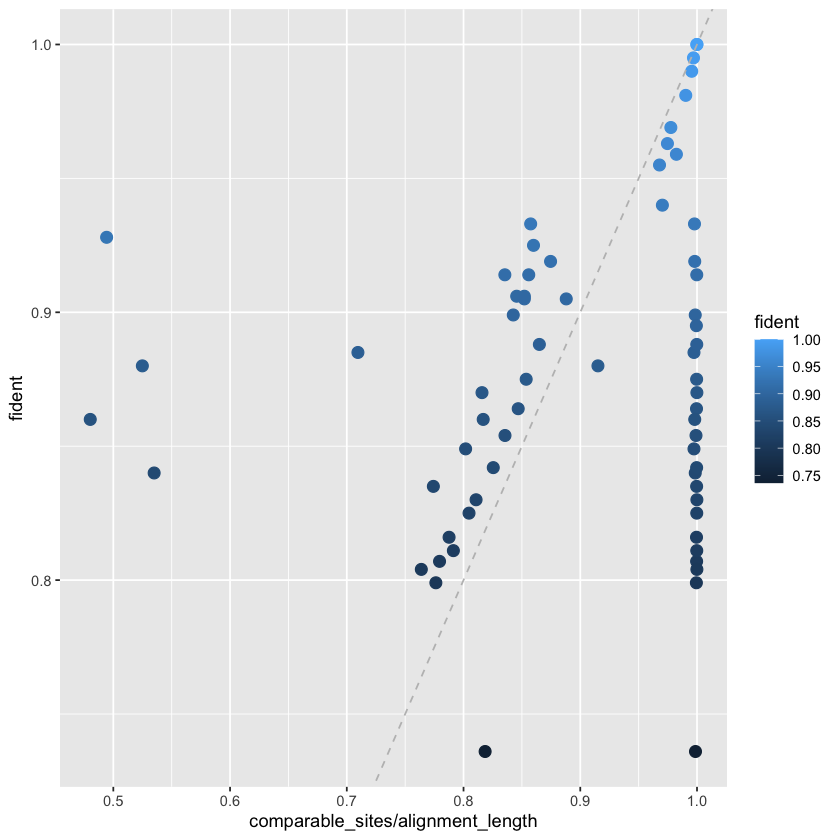

In [38]:
selection %>%
  mutate(target = factor(target, levels=mmseqs_ordered$target)) %>%
  ggplot(aes(y=fident, x=comparable_sites/alignment_length, color=fident)) +
    geom_point(size=3)+
    geom_abline(slope=1, intercept=0, linetype="dashed", color="gray")

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 8)

# Calculate the threshold where duplicates stop appearing
# (the x value after which each x-position has only one unique y value)
threshold_data <- selection %>%
    arrange(comparable_sites/alignment_length, fident) %>%
    group_by(comparable_sites/alignment_length) %>%
    summarise(n_per_x = n(), .groups = "drop") %>%
    filter(n_per_x > 1) %>%
    summarise(threshold = max(`comparable_sites/alignment_length`))

threshold_value <- threshold_data$threshold[1]

# Create the plot
ggplot(selection, aes(x = comparable_sites/alignment_length, y = fident)) +
    # Add vertical line at threshold
    geom_vline(
        xintercept = threshold_value,
        linetype = "dashed",
        color = "#E41A1C",
        linewidth = 0.8,
        alpha = 0.7
    ) +
    # Add shaded region before threshold
    annotate(
        "rect",
        xmin = -Inf, xmax = threshold_value,
        ymin = -Inf, ymax = Inf,
        fill = "#E41A1C",
        alpha = 0.05
    ) +
    # Add diagonal reference line
    geom_abline(
        slope = 1,
        intercept = 0,
        linetype = "dotted",
        color = "gray40",
        linewidth = 0.6
    ) +
    # Add points
    geom_point(
        aes(color = fident),
        size = 3.5,
        alpha = 0.8
    ) +
    # Color scale
    scale_color_gradient(
        low = "#4292C6",
        high = "#08519C",
        labels = scales::percent_format(accuracy = 1),
        guide = guide_colorbar(
            title = "Sequence\nIdentity",
            title.position = "top",
            barwidth = 1,
            barheight = 12
        )
    ) +
    # Axis scales
    scale_x_continuous(
        labels = scales::percent_format(accuracy = 1),
        breaks = scales::pretty_breaks(n = 6),
        expand = expansion(mult = c(0.02, 0.02))
    ) +
    scale_y_continuous(
        labels = scales::percent_format(accuracy = 1),
        breaks = scales::pretty_breaks(n = 6),
        expand = expansion(mult = c(0.02, 0.02))
    ) +
    # Labels
    labs(
        x = "Comparable Sites / Alignment Length",
        y = "Sequence Identity (fident)",
        title = "Sequence Identity vs Alignment Coverage",
        subtitle = sprintf(
            "Red dashed line indicates threshold (%.1f%%) where duplicate alignments cease",
            threshold_value * 100
        )
    ) +
    # Theme
    theme_minimal(base_size = 14) +
    theme(
        axis.title.x = element_text(margin = margin(t = 10), face = "bold"),
        axis.title.y = element_text(margin = margin(r = 10), face = "bold"),
        panel.grid.minor = element_blank(),
        panel.grid.major = element_line(color = "gray90"),
        panel.background = element_rect(fill = "white", color = NA),
        plot.background = element_rect(fill = "white", color = NA),
        legend.position = "right",
        legend.title = element_text(face = "bold", size = 11),
        legend.text = element_text(size = 10),
        plot.title = element_text(hjust = 0.5, face = "bold", size = 16),
        plot.subtitle = element_text(hjust = 0.5, size = 11, color = "gray30")
    )

Warning message in geom_hline(xintercept = threshold_value, linetype = "dashed", :
“Ignoring unknown parameters: `xintercept`”
ERROR while rich displaying an object: Error in `geom_hline()`:
! Problem while setting up geom.
ℹ Error occurred in the 1st layer.
Caused by error in `compute_geom_1()`:
! `geom_hline()` requires the following missing aesthetics: yintercept.

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .

In [46]:
selection%>%filter(got %in% c("Arya", "Sansa", "Jon"))

seq1_id,seq2_id,alignment_length,comparable_sites,matches,mismatches,mismatch_rate,seq1_length,seq2_length,seq1_gaps,seq2_gaps,seq1_Ns,seq2_Ns,got,dist_cons_to_ref,input_genomes,best_match
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>
Arya_cl55_it2.consensus_bcftools,MN090277.1,12469,7598,7573,1567,0.206238,12402,9232,67,3237,57,0,Arya,1,"MN090240.1, MN090277.1",MN090240.1
Arya_cl56_it2.consensus_bcftools,MN090277.1,9478,9012,8851,199,0.022082,9457,9232,9,246,400,0,Arya,1,"MN090240.1, MN090277.1",MN090277.1
Jon_cl60_it2.consensus_bcftools,MN090277.1,12532,7723,7612,1391,0.180111,12414,9232,118,3300,141,0,Jon,1,"MN090240.1, MN090277.1",MN090277.1
Jon_cl62_it2.consensus_bcftools,MN090277.1,9297,9167,9008,42,0.004582,9274,9232,0,65,221,0,Jon,1,"MN090240.1, MN090277.1",MN090277.1
Jon_cl92_it2.consensus_bcftools,MN090277.1,9700,2080,2080,38,0.018269,2584,9232,7114,468,0,0,Jon,1,"MN090240.1, MN090277.1",MN090277.1
Sansa_cl87_it2.consensus_bcftools,MN090277.1,12511,7702,7697,1421,0.184498,12402,9232,109,3279,23,0,Sansa,1,"MN090240.1, MN090277.1",MN090277.1
Sansa_cl88_it2.consensus_bcftools,MN090277.1,9297,9048,8889,171,0.018899,9284,9232,9,65,221,0,Sansa,1,"MN090240.1, MN090277.1",MN090277.1
